# Cross-scenario summary plots of the burden-based decomposition

This reads `02_run_magicc_burden_based.py`'s output, consistent with the official 
CMIP7 ScenarioMIP workflow's input convention. Output files are prefixed `consistent_` 
(e.g. `consistent_summary_burden_erf_2050_2100.png`).

## Imports

In [1]:
from pathlib import Path

from pandas_openscm.db import FeatherDataBackend, FeatherIndexBackend, OpenSCMDB

import attribution_common as ac

## Configuration

In [2]:
EMBARGOED = True
"""Set True once running against real (embargoed) ScenarioMIP scenarios - reads from
data/embargoed/ instead of plain data/. Must match 002's own EMBARGOED setting."""
DATA_DIR = Path("../data/embargoed") if EMBARGOED else Path("../data")

BASE_SCENARIOS = ac.load_base_scenarios(DATA_DIR)
"""Auto-discovered from 001's base_scenarios.json manifest."""

YEARS_TO_PLOT = [2050, 2100]
REGION = ac.REGION

BURDEN_SCM_OUTPUT_DB_DIR = DATA_DIR / "consistent_burden_scm_output_db"
BURDEN_GSAT_DB_DIR = DATA_DIR / "consistent_burden_gsat_db"
"""002's output dirs."""

PLOTS_DIR = Path("../data/plots")
"""Always plain data/plots/, regardless of EMBARGOED - plots and summary tables are not
considered sensitive, only raw emissions/MAGICC output."""
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PREFIX = "consistent_"
"""Prepended to every plot filename below."""

FORCING_CATEGORIES = {
    "CO2": "Effective Radiative Forcing|CO2",
    "CH4": "Effective Radiative Forcing|CH4",
    "N2O": "Effective Radiative Forcing|N2O",
    "F-Gases": "Effective Radiative Forcing|F-Gases",
    "Montreal Protocol Halogen Gases": "Effective Radiative Forcing|Montreal Protocol Halogen Gases",
    "Tropospheric Ozone": "Effective Radiative Forcing|Tropospheric Ozone",
    "Stratospheric Ozone": "Effective Radiative Forcing|Stratospheric Ozone",
    "Stratospheric H2O": "Effective Radiative Forcing|CH4 Oxidation Stratospheric H2O",
    "Aerosol-Radiation Interactions": "Effective Radiative Forcing|Aerosols|Direct Effect",
    "Aerosol-Cloud Interactions": "Effective Radiative Forcing|Aerosols|Indirect Effect",
    "Black Carbon on Snow": "Effective Radiative Forcing|Black Carbon on Snow",
    "Land Use": "Effective Radiative Forcing|Land-use Change",
    "Contrails and Aviation-Induced Cirrus": "Effective Radiative Forcing|Aviation|Contrail and Cirrus",
    "Solar": "Effective Radiative Forcing|Solar",
    "Volcanic": "Effective Radiative Forcing|Volcanic",
}
"""Must match 002's FORCING_CATEGORIES; kept in sync manually since
it's a config constant, not shared machinery."""

STACK_BUCKETS = {
    "CO2": ["CO2"],
    "N2O": ["N2O"],
    "CH4": ["CH4"],
    "Montreal Protocol Halogen Gases": ["Montreal Protocol Halogen Gases"],
    "Tropospheric Ozone": ["Tropospheric Ozone"],
    "F-Gases": ["F-Gases"],
    "Stratospheric H2O": ["Stratospheric H2O"],
    "Aerosol-Cloud Interactions": ["Aerosol-Cloud Interactions"],
    "Aerosol-Radiation Interactions": ["Aerosol-Radiation Interactions"],
    "Black Carbon on Snow": ["Black Carbon on Snow"],
    "Other": ["Stratospheric Ozone", "Solar", "Volcanic"],
}

BUCKET_COLORS = {
    "Aerosol-Radiation Interactions": "purple",
    "Aerosol-Cloud Interactions": "#B19CD9",
    "CO2": "#707070",
    "CH4": "LightSkyBlue",
    "N2O": "orange",
    "Montreal Protocol Halogen Gases": "cyan",
    "F-Gases": "blue",
    "Tropospheric Ozone": "yellow",
    "Stratospheric H2O": "magenta",
    "Black Carbon on Snow": "saddlebrown",
    "Other": "red",
}

## Load shared data

In [3]:
burden_scm_output = OpenSCMDB(
    backend_data=FeatherDataBackend(), backend_index=FeatherIndexBackend(), db_dir=BURDEN_SCM_OUTPUT_DB_DIR
).load(out_columns_type=int)
burden_scm_output.columns.name = "year"

burden_gsat_by_channel = OpenSCMDB(
    backend_data=FeatherDataBackend(), backend_index=FeatherIndexBackend(), db_dir=BURDEN_GSAT_DB_DIR
).load(out_columns_type=int)
burden_gsat_by_channel.columns.name = "year"
burden_gsat_by_channel = burden_gsat_by_channel.loc[
    (burden_gsat_by_channel.index.get_level_values("variable") == "Surface Air Temperature Change")
    & (burden_gsat_by_channel.index.get_level_values("region") == REGION)
]


def _to_matrix(sub):
    """Reshape a (scenario/variable/region/run_id)-indexed slice into a plain
    run_id-indexed, year-column matrix, as `ac.rebase_gsat_matrix` expects."""
    sub = sub.reset_index().set_index("run_id")
    year_columns = [c for c in sub.columns if isinstance(c, int)]
    return sub[year_columns].sort_index()


def category_gsat_matrix(base_scenario, category):
    """Rebased to the IPCC-standard 1850-1900 reference period. Only used
    for the *absolute* GSAT plot below - the delta-relative-to-2025 plot further down
    is already baseline-invariant (a constant rebase shift cancels in any delta of the
    same run against itself), so it deliberately keeps reading un-rebased data. Shares
    `base_scenario`'s real total run's own assessment-matching shift
    (`ac.gsat_assessment_shift`) rather than independently recalibrating this one
    category to the full AR6-assessed 0.85K on its own - see
    `ac.rebase_gsat_channel_matrix`'s docstring for why that distinction matters."""
    scenario = f"{base_scenario}_forcing_only_{category}"
    mask = burden_gsat_by_channel.index.get_level_values("scenario") == scenario
    shift = ac.gsat_assessment_shift(_raw_total_gsat_matrix(base_scenario), n_channels=len(FORCING_CATEGORIES))
    return ac.rebase_gsat_channel_matrix(_to_matrix(burden_gsat_by_channel.loc[mask]), shift)


def _raw_total_gsat_matrix(base_scenario):
    mask = (
        (burden_scm_output.index.get_level_values("scenario") == base_scenario)
        & (burden_scm_output.index.get_level_values("variable") == "Surface Air Temperature Change")
        & (burden_scm_output.index.get_level_values("region") == REGION)
    )
    return _to_matrix(burden_scm_output.loc[mask])


def total_gsat_matrix(base_scenario):
    """Rebased - see `category_gsat_matrix` above."""
    return ac.rebase_gsat_matrix(_raw_total_gsat_matrix(base_scenario))


def category_member_series(base_scenario, category, year):
    """Un-rebased (native MAGICC baseline) - used only by the delta-relative-to-2025
    section, where rebasing would be a no-op anyway (see `category_gsat_matrix`)."""
    scenario = f"{base_scenario}_forcing_only_{category}"
    mask = burden_gsat_by_channel.index.get_level_values("scenario") == scenario
    return ac.member_series(burden_gsat_by_channel.loc[mask], year)


def total_gsat_member_series(base_scenario, year):
    """Un-rebased - see `category_member_series` above."""
    mask = (
        (burden_scm_output.index.get_level_values("scenario") == base_scenario)
        & (burden_scm_output.index.get_level_values("variable") == "Surface Air Temperature Change")
        & (burden_scm_output.index.get_level_values("region") == REGION)
    )
    return ac.member_series(burden_scm_output.loc[mask], year)

## Compute per-(scenario, year) bucket values and reference markers

Member-level discipline throughout: sum each bucket's underlying categories' per-member
series first (aligned on `run_id`), *then* take the median of the summed series - never
`sum(median(a), median(b), ...)`. Same for "Sum of attributed" (all 15 categories).

In [4]:
bucket_values = {bucket: {} for bucket in STACK_BUCKETS}
reference_markers_values = {"Total GSAT": {}, "Sum of attributed": {}}

for base_scenario in BASE_SCENARIOS:
    short_name = ac.scenario_short_name(base_scenario)
    category_matrices = {c: category_gsat_matrix(base_scenario, c) for c in FORCING_CATEGORIES}
    total_matrix = total_gsat_matrix(base_scenario)

    for year in YEARS_TO_PLOT:
        category_series = {c: category_matrices[c][year] for c in FORCING_CATEGORIES}

        for bucket, members in STACK_BUCKETS.items():
            bucket_sum = sum(category_series[c] for c in members)
            bucket_values[bucket][(short_name, year)] = bucket_sum.median()

        all_categories_sum = sum(category_series.values())
        reference_markers_values["Sum of attributed"][(short_name, year)] = all_categories_sum.median()
        reference_markers_values["Total GSAT"][(short_name, year)] = total_matrix[year].median()

## Additivity spot-check

Sum of all 15 categories (median of the per-member sum) vs. the real Total GSAT - same
reconstruction-residual check used throughout this project, here at the summary-plot
level rather than per-channel.

In [5]:
for base_scenario in BASE_SCENARIOS:
    short_name = ac.scenario_short_name(base_scenario)
    for year in YEARS_TO_PLOT:
        attributed = reference_markers_values["Sum of attributed"][(short_name, year)]
        total = reference_markers_values["Total GSAT"][(short_name, year)]
        print(f"{short_name} {year}: sum of attributed={attributed:+.4f} K, total GSAT={total:+.4f} K, residual={attributed - total:+.4f} K")

VL 2050: sum of attributed=+1.6540 K, total GSAT=+1.6751 K, residual=-0.0211 K
VL 2100: sum of attributed=+1.3639 K, total GSAT=+1.3667 K, residual=-0.0028 K
L 2050: sum of attributed=+1.7437 K, total GSAT=+1.7608 K, residual=-0.0172 K
L 2100: sum of attributed=+1.5999 K, total GSAT=+1.6210 K, residual=-0.0211 K
LN 2050: sum of attributed=+1.8250 K, total GSAT=+1.8422 K, residual=-0.0172 K
LN 2100: sum of attributed=+1.4552 K, total GSAT=+1.4651 K, residual=-0.0099 K
M 2050: sum of attributed=+1.8968 K, total GSAT=+1.9050 K, residual=-0.0083 K
M 2100: sum of attributed=+2.8120 K, total GSAT=+2.8298 K, residual=-0.0178 K
ML 2050: sum of attributed=+1.8776 K, total GSAT=+1.8822 K, residual=-0.0045 K
ML 2100: sum of attributed=+2.2167 K, total GSAT=+2.2303 K, residual=-0.0135 K
H 2050: sum of attributed=+2.0034 K, total GSAT=+2.0165 K, residual=-0.0131 K
H 2100: sum of attributed=+3.3954 K, total GSAT=+3.4230 K, residual=-0.0276 K
HL 2050: sum of attributed=+2.0032 K, total GSAT=+2.0183 K

## Plot

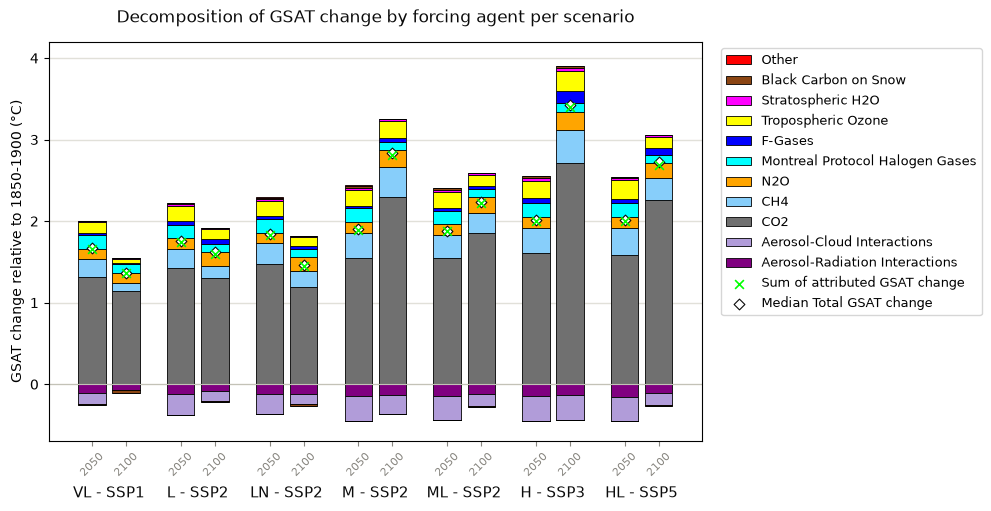

In [6]:
scenario_order = [ac.scenario_short_name(s) for s in BASE_SCENARIOS]
scenario_labels = [ac.scenario_display_label(s) for s in BASE_SCENARIOS]

reference_markers = [
    {
        "label": "Median Total GSAT change",
        "values": reference_markers_values["Total GSAT"],
        "marker": "D",
        "facecolor": ac.COLOR_SURFACE,
        "edgecolor": ac.COLOR_PRIMARY_TEXT,
        "size": 30,
        "linewidths": 0.8,
    },
    {
        "label": "Sum of attributed GSAT change",
        "values": reference_markers_values["Sum of attributed"],
        "marker": "x",
        "color": "lime",
        "size": 40,
        "linewidths": 1.2,
    },
]

ac.plot_scenario_year_stacked_bars(
    bucket_values=bucket_values,
    bucket_colors=BUCKET_COLORS,
    reference_markers=reference_markers,
    scenario_order=scenario_order,
    scenario_labels=scenario_labels,
    years=YEARS_TO_PLOT,
    title="Decomposition of GSAT change by forcing agent per scenario",
    ylabel=r"GSAT change relative to 1850-1900 (°C)",
    ylim=(-0.7,4.2),
    out_path=PLOTS_DIR / f"{OUTPUT_PREFIX}summary_burden_attribution_{'_'.join(str(y) for y in YEARS_TO_PLOT)}.png",
);

## Diagnostic: same plot with no rebasing at all

`category_gsat_matrix`/`total_gsat_matrix` above rebase to the
IPCC-standard 1850-1900 reference period; this instead plots the raw, unaltered
MAGICC output directly, as an independent confirmation of additivity.

In [7]:
def _raw_category_gsat_matrix(base_scenario, category):
    """Un-rebased counterpart to `category_gsat_matrix`."""
    scenario = f"{base_scenario}_forcing_only_{category}"
    mask = burden_gsat_by_channel.index.get_level_values("scenario") == scenario
    return _to_matrix(burden_gsat_by_channel.loc[mask])


raw_bucket_values = {bucket: {} for bucket in STACK_BUCKETS}
raw_reference_markers_values = {"Total GSAT": {}, "Sum of attributed": {}}

for base_scenario in BASE_SCENARIOS:
    short_name = ac.scenario_short_name(base_scenario)
    category_matrices = {c: _raw_category_gsat_matrix(base_scenario, c) for c in FORCING_CATEGORIES}
    total_matrix = _raw_total_gsat_matrix(base_scenario)

    for year in YEARS_TO_PLOT:
        category_series = {c: category_matrices[c][year] for c in FORCING_CATEGORIES}

        for bucket, members in STACK_BUCKETS.items():
            bucket_sum = sum(category_series[c] for c in members)
            raw_bucket_values[bucket][(short_name, year)] = bucket_sum.median()

        all_categories_sum = sum(category_series.values())
        raw_reference_markers_values["Sum of attributed"][(short_name, year)] = all_categories_sum.median()
        raw_reference_markers_values["Total GSAT"][(short_name, year)] = total_matrix[year].median()

In [8]:
for base_scenario in BASE_SCENARIOS:
    short_name = ac.scenario_short_name(base_scenario)
    for year in YEARS_TO_PLOT:
        attributed = raw_reference_markers_values["Sum of attributed"][(short_name, year)]
        total = raw_reference_markers_values["Total GSAT"][(short_name, year)]
        print(
            f"{short_name} {year} (raw, unrebased): sum of attributed={attributed:+.4f} K, "
            f"total GSAT={total:+.4f} K, residual={attributed - total:+.4f} K"
        )

VL 2050 (raw, unrebased): sum of attributed=+1.7941 K, total GSAT=+1.7975 K, residual=-0.0035 K
VL 2100 (raw, unrebased): sum of attributed=+1.4999 K, total GSAT=+1.4903 K, residual=+0.0096 K
L 2050 (raw, unrebased): sum of attributed=+1.8916 K, total GSAT=+1.8838 K, residual=+0.0078 K
L 2100 (raw, unrebased): sum of attributed=+1.7431 K, total GSAT=+1.7424 K, residual=+0.0007 K
LN 2050 (raw, unrebased): sum of attributed=+1.9673 K, total GSAT=+1.9680 K, residual=-0.0007 K
LN 2100 (raw, unrebased): sum of attributed=+1.5945 K, total GSAT=+1.5891 K, residual=+0.0054 K
M 2050 (raw, unrebased): sum of attributed=+2.0310 K, total GSAT=+2.0234 K, residual=+0.0076 K
M 2100 (raw, unrebased): sum of attributed=+2.9435 K, total GSAT=+2.9625 K, residual=-0.0190 K
ML 2050 (raw, unrebased): sum of attributed=+2.0174 K, total GSAT=+2.0076 K, residual=+0.0098 K
ML 2100 (raw, unrebased): sum of attributed=+2.3649 K, total GSAT=+2.3606 K, residual=+0.0042 K
H 2050 (raw, unrebased): sum of attributed=+

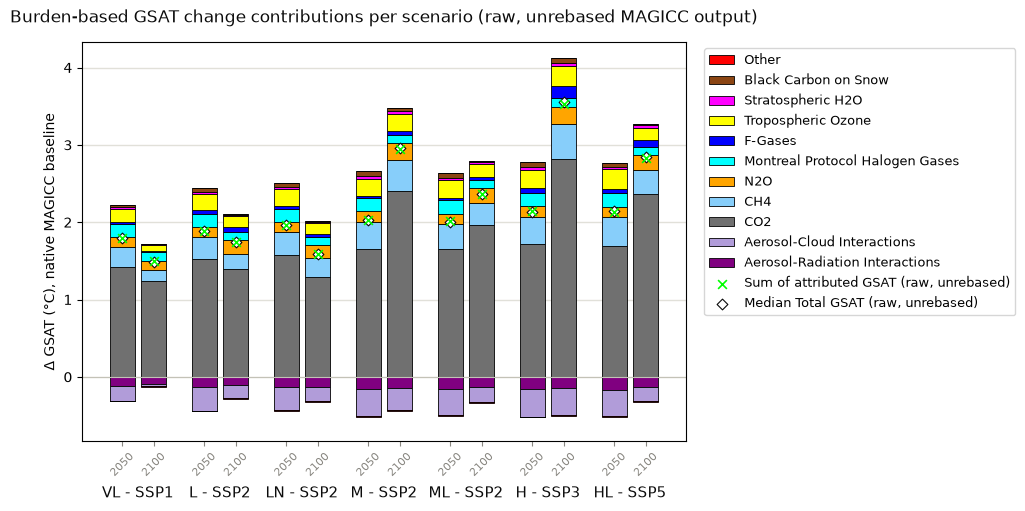

In [9]:
raw_reference_markers = [
    {
        "label": "Median Total GSAT (raw, unrebased)",
        "values": raw_reference_markers_values["Total GSAT"],
        "marker": "D",
        "facecolor": ac.COLOR_SURFACE,
        "edgecolor": ac.COLOR_PRIMARY_TEXT,
        "size": 30,
        "linewidths": 0.8,
    },
    {
        "label": "Sum of attributed GSAT (raw, unrebased)",
        "values": raw_reference_markers_values["Sum of attributed"],
        "marker": "x",
        "color": "lime",
        "size": 40,
        "linewidths": 1.2,
    },
]

ac.plot_scenario_year_stacked_bars(
    bucket_values=raw_bucket_values,
    bucket_colors=BUCKET_COLORS,
    reference_markers=raw_reference_markers,
    scenario_order=scenario_order,
    scenario_labels=scenario_labels,
    years=YEARS_TO_PLOT,
    title="Burden-based GSAT change contributions per scenario (raw, unrebased MAGICC output)",
    ylabel=r"$\Delta$ GSAT (°C), native MAGICC baseline",
    out_path=PLOTS_DIR / f"{OUTPUT_PREFIX}summary_burden_attribution_raw_unrebased_{'_'.join(str(y) for y in YEARS_TO_PLOT)}.png",
);

## Compute deltas relative to 2025

Same member-level discipline as above: for each bucket/marker, subtract the 2025
per-member value from each of `YEARS_TO_PLOT`'s per-member value (aligned - same
scenario/category, just a different year column, so indices already match), *then*
take the median of that per-member delta.

In [10]:
BASELINE_YEAR = 2025

bucket_values_delta = {bucket: {} for bucket in STACK_BUCKETS}
reference_markers_values_delta = {"Total GSAT": {}, "Sum of attributed": {}}

for base_scenario in BASE_SCENARIOS:
    short_name = ac.scenario_short_name(base_scenario)
    category_series_baseline = {c: category_member_series(base_scenario, c, BASELINE_YEAR) for c in FORCING_CATEGORIES}
    total_gsat_baseline = total_gsat_member_series(base_scenario, BASELINE_YEAR)

    for year in YEARS_TO_PLOT:
        category_series = {c: category_member_series(base_scenario, c, year) for c in FORCING_CATEGORIES}

        for bucket, members in STACK_BUCKETS.items():
            bucket_sum = sum(category_series[c] for c in members)
            bucket_sum_baseline = sum(category_series_baseline[c] for c in members)
            bucket_values_delta[bucket][(short_name, year)] = (bucket_sum - bucket_sum_baseline).median()

        all_categories_sum = sum(category_series.values())
        all_categories_sum_baseline = sum(category_series_baseline.values())
        reference_markers_values_delta["Sum of attributed"][(short_name, year)] = (
            all_categories_sum - all_categories_sum_baseline
        ).median()
        reference_markers_values_delta["Total GSAT"][(short_name, year)] = (
            total_gsat_member_series(base_scenario, year) - total_gsat_baseline
        ).median()

## Plot: deltas relative to 2025

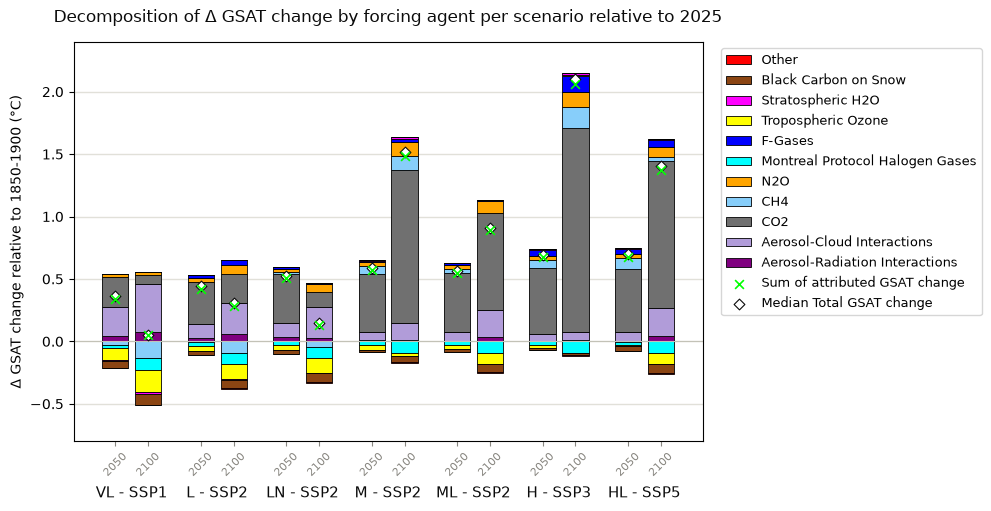

In [11]:
reference_markers_delta = [
    {
        "label": "Median Total GSAT change",
        "values": reference_markers_values_delta["Total GSAT"],
        "marker": "D",
        "facecolor": ac.COLOR_SURFACE,
        "edgecolor": ac.COLOR_PRIMARY_TEXT,
        "size": 30,
        "linewidths": 0.8,
    },
    {
        "label": "Sum of attributed GSAT change",
        "values": reference_markers_values_delta["Sum of attributed"],
        "marker": "x",
        "color": "lime",
        "size": 40,
        "linewidths": 1.2,
    },
]

ac.plot_scenario_year_stacked_bars(
    bucket_values=bucket_values_delta,
    bucket_colors=BUCKET_COLORS,
    reference_markers=reference_markers_delta,
    scenario_order=scenario_order,
    scenario_labels=scenario_labels,
    years=YEARS_TO_PLOT,
    ylim=(-0.8, 2.4),
    title=r"Decomposition of $\Delta$ GSAT change by forcing agent per scenario relative to 2025",
    ylabel=r"$\Delta$ GSAT change relative to 1850-1900 (°C)",
    out_path=PLOTS_DIR / f"{OUTPUT_PREFIX}summary_burden_attribution_delta_2025_{'_'.join(str(y) for y in YEARS_TO_PLOT)}.png",
);

# ERF versions of the two plots above

Same buckets/markers/layout, but reading each category's own
`Effective Radiative Forcing|<category>` variable directly off the real base-scenario
run (`burden_scm_output`) instead of the QEXTRA `forcing_only_<category>` GSAT
channels - ERF per category doesn't need a QEXTRA rerun, MAGICC already reports it
for the single real run. "Total ERF" (the reference marker analogous to Total GSAT)
is 002's `OUTPUT_VARIABLES`'s "Effective Radiative Forcing".

## ERF: helpers

In [12]:
def category_erf_member_series(base_scenario, category, year):
    return ac.member_series(
        ac.load_erf(burden_scm_output, base_scenario, FORCING_CATEGORIES[category], region=REGION), year
    )


def total_erf_member_series(base_scenario, year):
    return ac.member_series(
        ac.load_erf(burden_scm_output, base_scenario, "Effective Radiative Forcing", region=REGION), year
    )

## ERF: compute per-(scenario, year) bucket values and reference markers

In [13]:
erf_bucket_values = {bucket: {} for bucket in STACK_BUCKETS}
erf_reference_markers_values = {"Total ERF": {}, "Sum of attributed": {}}

for base_scenario in BASE_SCENARIOS:
    short_name = ac.scenario_short_name(base_scenario)
    for year in YEARS_TO_PLOT:
        category_series = {c: category_erf_member_series(base_scenario, c, year) for c in FORCING_CATEGORIES}

        for bucket, members in STACK_BUCKETS.items():
            bucket_sum = sum(category_series[c] for c in members)
            erf_bucket_values[bucket][(short_name, year)] = bucket_sum.median()

        all_categories_sum = sum(category_series.values())
        erf_reference_markers_values["Sum of attributed"][(short_name, year)] = all_categories_sum.median()
        erf_reference_markers_values["Total ERF"][(short_name, year)] = total_erf_member_series(base_scenario, year).median()

## ERF: additivity spot-check

In [14]:
for base_scenario in BASE_SCENARIOS:
    short_name = ac.scenario_short_name(base_scenario)
    for year in YEARS_TO_PLOT:
        attributed = erf_reference_markers_values["Sum of attributed"][(short_name, year)]
        total = erf_reference_markers_values["Total ERF"][(short_name, year)]
        print(f"{short_name} {year}: sum of attributed={attributed:+.4f} W/m^2, total ERF={total:+.4f} W/m^2, residual={attributed - total:+.4f} W/m^2")

VL 2050: sum of attributed=+3.2925 W/m^2, total ERF=+3.2520 W/m^2, residual=+0.0405 W/m^2
VL 2100: sum of attributed=+2.3956 W/m^2, total ERF=+2.3754 W/m^2, residual=+0.0201 W/m^2
L 2050: sum of attributed=+3.5406 W/m^2, total ERF=+3.5065 W/m^2, residual=+0.0342 W/m^2
L 2100: sum of attributed=+2.8780 W/m^2, total ERF=+2.8567 W/m^2, residual=+0.0213 W/m^2
LN 2050: sum of attributed=+3.6990 W/m^2, total ERF=+3.6582 W/m^2, residual=+0.0408 W/m^2
LN 2100: sum of attributed=+2.5005 W/m^2, total ERF=+2.4782 W/m^2, residual=+0.0223 W/m^2
M 2050: sum of attributed=+3.9304 W/m^2, total ERF=+3.8926 W/m^2, residual=+0.0377 W/m^2
M 2100: sum of attributed=+5.3393 W/m^2, total ERF=+5.2838 W/m^2, residual=+0.0555 W/m^2
ML 2050: sum of attributed=+3.8881 W/m^2, total ERF=+3.8492 W/m^2, residual=+0.0388 W/m^2
ML 2100: sum of attributed=+4.0092 W/m^2, total ERF=+3.9699 W/m^2, residual=+0.0393 W/m^2
H 2050: sum of attributed=+4.2195 W/m^2, total ERF=+4.1767 W/m^2, residual=+0.0428 W/m^2
H 2100: sum of 

## ERF: plot

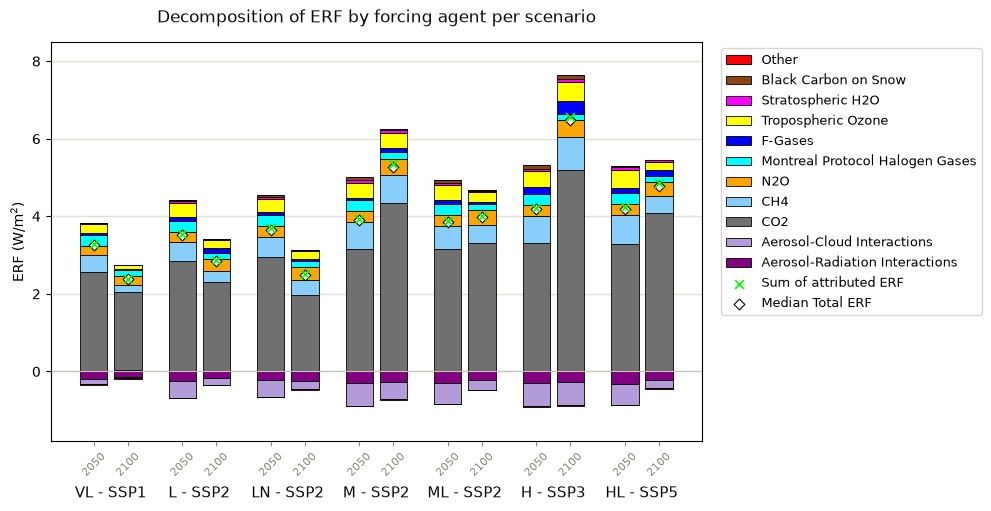

In [15]:
erf_reference_markers = [
    {
        "label": "Median Total ERF",
        "values": erf_reference_markers_values["Total ERF"],
        "marker": "D",
        "facecolor": ac.COLOR_SURFACE,
        "edgecolor": ac.COLOR_PRIMARY_TEXT,
        "size": 30,
        "linewidths": 0.8,
    },
    {
        "label": "Sum of attributed ERF",
        "values": erf_reference_markers_values["Sum of attributed"],
        "marker": "x",
        "color": "lime",
        "size": 40,
        "linewidths": 1.2,
    },
]

ac.plot_scenario_year_stacked_bars(
    bucket_values=erf_bucket_values,
    bucket_colors=BUCKET_COLORS,
    reference_markers=erf_reference_markers,
    scenario_order=scenario_order,
    scenario_labels=scenario_labels,
    years=YEARS_TO_PLOT,
    ylim=(-1.8,8.5),
    title="Decomposition of ERF by forcing agent per scenario",
    ylabel="ERF (W/m$^2$)",
    out_path=PLOTS_DIR / f"{OUTPUT_PREFIX}summary_burden_erf_{'_'.join(str(y) for y in YEARS_TO_PLOT)}.png",
);

## ERF: compute deltas relative to 2025

In [16]:
erf_bucket_values_delta = {bucket: {} for bucket in STACK_BUCKETS}
erf_reference_markers_values_delta = {"Total ERF": {}, "Sum of attributed": {}}

for base_scenario in BASE_SCENARIOS:
    short_name = ac.scenario_short_name(base_scenario)
    category_series_baseline = {c: category_erf_member_series(base_scenario, c, BASELINE_YEAR) for c in FORCING_CATEGORIES}
    total_erf_baseline = total_erf_member_series(base_scenario, BASELINE_YEAR)

    for year in YEARS_TO_PLOT:
        category_series = {c: category_erf_member_series(base_scenario, c, year) for c in FORCING_CATEGORIES}

        for bucket, members in STACK_BUCKETS.items():
            bucket_sum = sum(category_series[c] for c in members)
            bucket_sum_baseline = sum(category_series_baseline[c] for c in members)
            erf_bucket_values_delta[bucket][(short_name, year)] = (bucket_sum - bucket_sum_baseline).median()

        all_categories_sum = sum(category_series.values())
        all_categories_sum_baseline = sum(category_series_baseline.values())
        erf_reference_markers_values_delta["Sum of attributed"][(short_name, year)] = (
            all_categories_sum - all_categories_sum_baseline
        ).median()
        erf_reference_markers_values_delta["Total ERF"][(short_name, year)] = (
            total_erf_member_series(base_scenario, year) - total_erf_baseline
        ).median()

## ERF: plot deltas relative to 2025

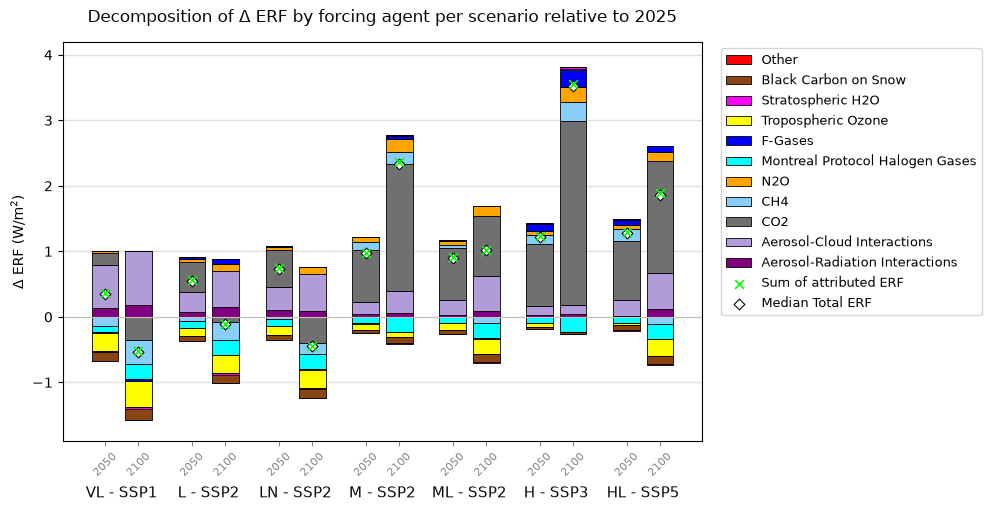

In [17]:
erf_reference_markers_delta = [
    {
        "label": "Median Total ERF",
        "values": erf_reference_markers_values_delta["Total ERF"],
        "marker": "D",
        "facecolor": ac.COLOR_SURFACE,
        "edgecolor": ac.COLOR_PRIMARY_TEXT,
        "size": 30,
        "linewidths": 0.8,
    },
    {
        "label": "Sum of attributed ERF",
        "values": erf_reference_markers_values_delta["Sum of attributed"],
        "marker": "x",
        "color": "lime",
        "size": 40,
        "linewidths": 1.2,
    },
]

ac.plot_scenario_year_stacked_bars(
    bucket_values=erf_bucket_values_delta,
    bucket_colors=BUCKET_COLORS,
    reference_markers=erf_reference_markers_delta,
    scenario_order=scenario_order,
    scenario_labels=scenario_labels,
    years=YEARS_TO_PLOT,
    ylim=(-1.9,4.2),
    title=r"Decomposition of $\Delta$ ERF by forcing agent per scenario relative to 2025",
    ylabel=r"$\Delta$ ERF (W/m$^2$)",
    out_path=PLOTS_DIR / f"{OUTPUT_PREFIX}summary_burden_erf_delta_2025_{'_'.join(str(y) for y in YEARS_TO_PLOT)}.png",
);

# Export underlying data to CSV

One combined CSV, wide on metric (ERF/GSAT contribution side by side), long on
scenario/species/year/quantile. Full quantile distributions (not just the median
shown in the bars), member-level-first (sum each species' categories' per-member
values first, *then* take quantiles) - matching this project's convention everywhere
else. `GSAT_contribution` is the rebased value relative to 1850-1900.

In [18]:
import pandas as pd

EXPORT_QUANTILES = [0.05, 0.10, 1 / 6, 0.33, 0.50, 0.67, 5 / 6, 0.90, 0.95]
"""Same 9-quantile convention used elsewhere in this project (e.g. the official
assessed-warming/ERF quantile CSVs, `repro_compare_erf_quantiles.py`)."""

EXPORT_YEARS = [2023, 2025, 2050, 2100]
"""Independent of `YEARS_TO_PLOT` (still just [2050, 2100] for the bar charts above) -
the CSV additionally covers 2023 (last year of historical emissions) and 2025 (the delta 
baseline used elsewhere in this project)."""

export_rows = []
for base_scenario in BASE_SCENARIOS:
    short_name = ac.scenario_short_name(base_scenario)
    for species, members in STACK_BUCKETS.items():
        gsat_matrix = sum(category_gsat_matrix(base_scenario, c) for c in members)
        for year in EXPORT_YEARS:
            gsat_at_year = gsat_matrix[year]
            erf_at_year = sum(category_erf_member_series(base_scenario, c, year) for c in members)
            for q in EXPORT_QUANTILES:
                export_rows.append(
                    {
                        "scenario": short_name,
                        "species": species,
                        "year": year,
                        "quantile": q,
                        "ERF_contribution (W/m^2)": erf_at_year.quantile(q),
                        "GSAT_contribution (°C)": gsat_at_year.quantile(q),
                    }
                )

export_df = pd.DataFrame(export_rows)
export_path = PLOTS_DIR / f"{OUTPUT_PREFIX}summary_burden_attribution.csv"
export_df.to_csv(export_path, index=False)
print(f"wrote {export_path} ({len(export_df)} rows)")

wrote ../data/plots/consistent_summary_burden_attribution.csv (2772 rows)
